## Solution 7

In [2]:
import numpy as np

rng = np.random.default_rng(seed=42)
step_size = 0.1

def xavier_weights_init(input_features: int, output_features: int) -> np.ndarray:
    limit = 6 / (input_features + output_features)
    return rng.uniform(-limit, limit, size=(output_features, input_features))

def sigmoid(z: np.ndarray) -> np.ndarray:
    return 1 / (1 + np.exp(-z))

def mean_squared_error(ypred: np.ndarray, y: np.ndarray) -> np.floating:
    return np.sum((y - ypred)**2) / 2

X = rng.uniform(-1, 1, size=(20, 2))   # shape (N,2)
y = np.expand_dims(X[:, 0]**2 + X[:, 1]**2, axis=1)  # shape (N,1); expand so it matches model output y shape
W1 = xavier_weights_init(input_features=2, output_features=5)   # shape (5,2)
W2 = xavier_weights_init(input_features=5, output_features=1)   # shape (1,5)
y1 = sigmoid(X @ W1.T)   # shape (N,5)
y2 = y1 @ W2.T      # shape (N,1)
loss = mean_squared_error(y2, y)

# gradient calculation
loss_dy2 = y2 - y         # shape (N,1)

loss_dW2 = loss_dy2.T @ y1   # shape (1,5)
loss_dy1 = loss_dy2 @ W2      # shape (N,5)

loss_dz1 = loss_dy1 * (y1 * (1 - y1))    # shape (N,5); multiply by sigmoid derivative
loss_dW1 = loss_dz1.T @ X    # shape (5,2)

W2 -= step_size * loss_dW2
W1 -= step_size * loss_dW1

In [3]:
loss

np.float64(7.71833596633478)

In [4]:
loss_dW1

array([[ 0.14134793,  0.52207301],
       [ 0.25175613,  0.87617801],
       [-0.0661926 , -0.4678341 ],
       [-0.06442901, -0.29304177],
       [-0.11228373, -0.35150184]])

In [5]:
loss_dW2

array([[-8.47790697, -7.77561024, -8.55490194, -7.61623414, -7.50858505]])

In [6]:
W1

array([[-0.12187436,  0.51809818],
       [ 0.31813599, -0.40927499],
       [ 0.57620749,  0.56923659],
       [-0.18645131, -0.33356193],
       [ 0.32407781, -0.58241699]])

In [7]:
W2

array([[ 0.2476071 , -0.20771444,  1.42933895,  1.09132513,  1.16118926]])

In [8]:
epsilon = 1e-5
W2_updated = W2.copy()
W2[0,0] -= epsilon
y1 = sigmoid(X @ W1)
y2 = y1 @ W2
loss_before = mean_squared_error(y2, y)
loss_before

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 5 is different from 2)

## Solution 1

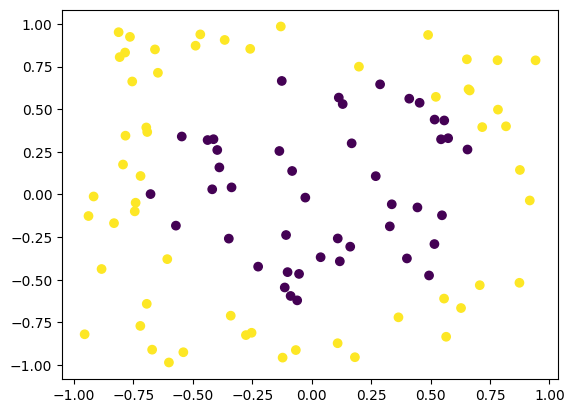

In [9]:
import numpy as np
from numpy.typing import NDArray
from matplotlib import pyplot as plt
from tqdm import trange

rng = np.random.default_rng(seed=42)
X = rng.uniform(-1, 1, size=(100,2))
y = np.where(X[:,0]**2 + X[:,1]**2 > 0.5, 1, 0)

# split into train & validation data
Xtrain, Xval = X[:80,:], X[80:]
ytrain, yval = y[:80], y[80:]

plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [25]:
y = np.expand_dims(y, axis=1)
y.shape

(100, 1)

In [29]:
def weights_init(curr_width: int, prev_width: int) -> NDArray[np.float64]:
    W = rng.normal(0, 0.1, size=(curr_width, prev_width))
    biases = np.zeros((curr_width, 1))
    return np.hstack([W, biases])

def relu(z: NDArray[np.float64]) -> NDArray[np.float64]:
    return np.maximum(0, z)

def sigmoid(z: NDArray[np.floating]) -> NDArray[np.float64]:
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y: NDArray[np.floating], yprobab: NDArray[np.float64]) -> np.float64:
    return np.sum(-y * np.log(yprobab) - (1-y) * np.log(1-yprobab))

def predict(weights: list[NDArray[np.float64]], X: NDArray[np.float64]) -> list[NDArray[np.float64]]:
    """Returns all data (numpy arrays) flowing between each layer."""
    data = [X]
    for W in weights[:-1]:         # hidden layer weights
        X = data[-1]
        augmented = np.hstack([X, np.ones((X.shape[0],1))])
        data.append(relu(augmented @ W.T)) 

    X = data[-1]
    augmented = np.hstack([X, np.ones((X.shape[0],1))])         
    data.append(sigmoid(augmented @ weights[-1].T))
    return data

def gradients(y: NDArray[np.float64], weights: list[NDArray[np.float64]], outputs: list[NDArray[np.float64]]):
    print('Data shapes:', [a.shape for a in outputs])
    print('Weight shapes:', [w.shape for w in weights])
    ylast = outputs[-1]
    grad_data = - y / ylast + (1-y) / (1-ylast) # derivative of binary cross entropy loss

    # last output layer has sigmoid activation
    Wlast = weights[-1]
    Xlast = outputs[-2]
    sigmoid_grad = ylast * (1 - ylast)
    print(f'{sigmoid_grad.shape=}, {Wlast.shape=}, {grad_data.shape=}')
    dX = sigmoid_grad @ Wlast
    grad_data = dX.T @ grad_data
    yield Xlast @ grad_data

    for X, y, W in zip(outputs[-2::-1], outputs[-3:1:-1], weights[-2::-1]):      # rest hidden layers have relu activation
        relu_grad = np.where(y > 0, 1, 0)
        dX = sigmoid_grad @ Wlast
        grad_data = dX.T @ grad_data
        yield X @ grad_data

model1_widths = [2, 20, 1]
model2_widths = [2, 10, 10, 1]
step_size = 0.01     # learning rate
max_epochs = 100

def train(layer_widths: list[int], X: NDArray[np.float64], y: NDArray[np.float64]):
    weights = [weights_init(curr_width, prev_width) for prev_width, curr_width in zip(layer_widths[:-1], layer_widths[1:])]
    train_losses = []
    for epoch in trange(max_epochs):
        outputs = predict(weights, X)
        yprobab = outputs[-1]
        loss = binary_cross_entropy(y, yprobab)
        train_losses.append(loss)

        # backpropogation gradient descent
        for i, grads in enumerate(gradients(y, weights, outputs), 1):
            weights[-i] -= step_size * grads      # -i as iter from last (reverse order of layers)
    return weights, train_losses

In [30]:
weights1, train_losses1 = train(model1_widths, X, y)

  0%|          | 0/100 [00:00<?, ?it/s]

Data shapes: [(100, 2), (100, 20), (100, 1)]
Weight shapes: [(20, 3), (1, 21)]
sigmoid_grad.shape=(100, 1), Wlast.shape=(1, 21), grad_data.shape=(100, 1)


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 21 is different from 20)